# DCGAN sur Chest X-Ray (Pneumonia Dataset)
## Génération d'images radiologiques par Deep Convolutional GAN

**Dataset** : Chest X-Rays (Pneumonia) — Paul Mooney / Kaggle
https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia

**Architecture** : DCGAN (Radford et al., 2015)
- Le **Générateur** transforme un vecteur de bruit $z \sim \mathcal{N}(0,I)$ en radiographie pulmonaire
- Le **Discriminateur** distingue vraies radiographies vs images synthétiques
- Pas d'encodeur — uniquement génération depuis le bruit

**Références** :
- DCGAN paper : https://arxiv.org/pdf/1511.06434
- GAN original : https://arxiv.org/pdf/1406.2661
- Wikipedia GAN : https://en.wikipedia.org/wiki/Generative_adversarial_network
- AdversarialNetsPapers : https://github.com/zhangqianhui/AdversarialNetsPapers

## 1. Imports et configuration

In [1]:
import os
import uuid
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')

PyTorch version : 2.10.0+cu128
GPU disponible  : True


**Commentaire :** On utilise `torchvision.datasets.ImageFolder` — parfait pour le dataset Chest X-Ray dont la structure est :
```
chest_xray/
  train/
    NORMAL/      ← images de poumons sains
    PNEUMONIA/   ← images avec pneumonie
  test/
    NORMAL/
    PNEUMONIA/
```
`ImageFolder` détecte automatiquement les sous-dossiers comme classes. Pour le GAN on ne distingue pas les classes (on génère des radio en général), mais la structure est commode pour charger toutes les images.

Pas besoin de `torch.nn.functional` ici : le DCGAN est plus simple que le VAE-GAN, toutes les losses sont dans `nn.BCELoss`.

## 2. Hyperparamètres configurables

In [2]:
# ── Hyperparamètres DCGAN (fidèles au papier Radford et al. 2015) ─────────
NUM_EPOCHS              = 50
NOISE_DIMENSION         = 100         # Dimension du vecteur latent z
BATCH_SIZE              = 64          # Taille de batch
IMAGE_SIZE              = 64          # Résolution : 64x64 (DCGAN standard)
IMAGE_CHANNELS          = 1           # Radio pulmonaire : niveaux de gris
FEATURES_G              = 64          # Taille de base des feature maps générateur
FEATURES_D              = 64          # Taille de base des feature maps discriminateur
TRAIN_ON_GPU            = True
UNIQUE_RUN_ID           = str(uuid.uuid4())
PRINT_STATS_AFTER_BATCH = 50
OPTIMIZER_LR            = 0.0002      # Recommandé par DCGAN paper
OPTIMIZER_BETAS         = (0.5, 0.999)  # Beta1=0.5 : recommandé DCGAN

# Chemin vers le dataset Chest X-Ray
DATA_ROOT = './data/chest_xray/train/'  # Adapter à votre installation

print('Configuration DCGAN :')
print(f'  Image size     : {IMAGE_SIZE}x{IMAGE_SIZE} px')
print(f'  Bruit latent   : {NOISE_DIMENSION}')
print(f'  Features G/D   : {FEATURES_G}/{FEATURES_D}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Époques        : {NUM_EPOCHS}')
print(f'  LR / Beta1     : {OPTIMIZER_LR} / {OPTIMIZER_BETAS[0]}')

Configuration DCGAN :
  Image size     : 64x64 px
  Bruit latent   : 100
  Features G/D   : 64/64
  Batch size     : 64
  Époques        : 50
  LR / Beta1     : 0.0002 / 0.5


In [3]:
import kagglehub
import os

# Download latest version of the dataset
print("Downloading dataset...")
download_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Construct the path to the 'train' directory
# Assuming the structure is 'download_path/chest_xray/train'
DATA_ROOT_DOWNLOADED = os.path.join(download_path, 'chest_xray', 'train')

print(f"Dataset downloaded to: {download_path}")
print(f"Setting DATA_ROOT to: {DATA_ROOT_DOWNLOADED}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Setting DATA_ROOT to: /kaggle/input/chest-xray-pneumonia/chest_xray/train


In [4]:
# ── Hyperparamètres DCGAN (fidèles au papier Radford et al. 2015) ─────────
NUM_EPOCHS              = 50
NOISE_DIMENSION         = 100         # Dimension du vecteur latent z
BATCH_SIZE              = 64          # Taille de batch
IMAGE_SIZE              = 64          # Résolution : 64x64 (DCGAN standard)
IMAGE_CHANNELS          = 1           # Radio pulmonaire : niveaux de gris
FEATURES_G              = 64          # Taille de base des feature maps générateur
FEATURES_D              = 64          # Taille de base des feature maps discriminateur
TRAIN_ON_GPU            = True
UNIQUE_RUN_ID           = str(uuid.uuid4())
PRINT_STATS_AFTER_BATCH = 50
OPTIMIZER_LR            = 0.0002      # Recommandé par DCGAN paper
OPTIMIZER_BETAS         = (0.5, 0.999)  # Beta1=0.5 : recommandé DCGAN

# Chemin vers le dataset Chest X-Ray
DATA_ROOT = DATA_ROOT_DOWNLOADED  # Adapter à votre installation

print('Configuration DCGAN :')
print(f'  Image size     : {IMAGE_SIZE}x{IMAGE_SIZE} px')
print(f'  Bruit latent   : {NOISE_DIMENSION}')
print(f'  Features G/D   : {FEATURES_G}/{FEATURES_D}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Époques        : {NUM_EPOCHS}')
print(f'  LR / Beta1     : {OPTIMIZER_LR} / {OPTIMIZER_BETAS[0]}')

Configuration DCGAN :
  Image size     : 64x64 px
  Bruit latent   : 100
  Features G/D   : 64/64
  Batch size     : 64
  Époques        : 50
  LR / Beta1     : 0.0002 / 0.5


**Commentaire :** Ces hyperparamètres sont **directement issus du paper DCGAN** (Radford, Metz, Chintala, 2015).

Valeurs cruciales :
- `OPTIMIZER_LR = 0.0002` : le DCGAN paper a montré empiriquement que $2 \times 10^{-4}$ est optimal pour la stabilité GAN
- `OPTIMIZER_BETAS = (0.5, 0.999)` : `beta1 = 0.5` (au lieu de 0.9 habituel) car les gradients GAN oscillent beaucoup — un momentum réduit évite les divergences
- `IMAGE_SIZE = 64` : résolution standard DCGAN, bon compromis qualité/vitesse. On pourrait monter à 128 ou 256 mais l'architecture doit être ajustée
- `FEATURES_G = FEATURES_D = 64` : facteur de base pour les feature maps. On multiplie par 2 à chaque couche du discriminateur, on divise par 2 dans le générateur

**Différence avec le VAE-GAN** : pas de `LATENT_DIM` car le DCGAN n'a pas d'encodeur — le bruit `z` est tiré directement de $\mathcal{N}(0,I)$ sans passer par une distribution apprise.

## 3. Optimisations GPU

In [5]:
# Speed ups (identiques au GAN de référence)
torch.autograd.set_detect_anomaly(False)
torch.autograd.profiler.profile(False)
torch.autograd.profiler.emit_nvtx(False)
torch.backends.cudnn.benchmark = True

def get_device():
    """ Retourne le device disponible. """
    return torch.device('cuda:0' if torch.cuda.is_available() and TRAIN_ON_GPU else 'cpu')

device = get_device()
print(f'Device : {device}')
print(f'cudnn.benchmark = {torch.backends.cudnn.benchmark}')

Device : cuda:0
cudnn.benchmark = True


**Commentaire :** Mêmes optimisations que dans le GAN original de référence.

`cudnn.benchmark = True` est particulièrement impactant ici car le DCGAN utilise **uniquement des convolutions** (contrairement au GAN vanilla qui utilise des Linear). CuDNN peut choisir l'algorithme de convolution optimal pour chaque couche.

**Conseil pratique** : si vous changez `IMAGE_SIZE` en cours d'entraînement, remettez `benchmark = False` temporairement car CuDNN doit re-profiler les convolutions pour la nouvelle taille.

## 4. Chargement du dataset Chest X-Ray

In [6]:
def prepare_dataset():
    """
    Prépare le DataLoader pour le dataset Chest X-Ray.
    Utilise ImageFolder qui gère automatiquement la structure NORMAL/PNEUMONIA.
    Pour le GAN, on ignore les labels (on génère des radios en général).
    """
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),                # Redimensionner le plus petit côté
        transforms.CenterCrop(IMAGE_SIZE),            # Recadrer au centre en carré
        transforms.Grayscale(num_output_channels=1),  # Forcer niveaux de gris
        transforms.ToTensor(),                         # [0,255] -> [0.0, 1.0]
        transforms.Normalize((0.5,), (0.5,))          # [0,1] -> [-1, 1]
    ])

    dataset = ImageFolder(root=DATA_ROOT, transform=transform)
    print(f'Dataset chargé : {len(dataset)} images')
    print(f'Classes trouvées : {dataset.classes}')

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True   # Évite les batches incomplets en fin d'époque
    )
    print(f'DataLoader : {len(dataloader)} batches')
    return dataloader


# Test rapide (décommentez si le dataset est disponible)
# loader = prepare_dataset()
# imgs, labels = next(iter(loader))
# print(f'Batch shape : {imgs.shape}')  # -> (64, 1, 64, 64)
# print(f'Pixel range : [{imgs.min():.2f}, {imgs.max():.2f}]')
print('Dataset function défini. Adaptez DATA_ROOT à votre chemin local.')
print('Téléchargement : kaggle datasets download paultimothymooney/chest-xray-pneumonia')

Dataset function défini. Adaptez DATA_ROOT à votre chemin local.
Téléchargement : kaggle datasets download paultimothymooney/chest-xray-pneumonia


**Commentaire :** `ImageFolder` est la solution la plus simple pour ce type de dataset organisé en sous-dossiers par classe.

Pipeline de transformation :
1. `Resize(64)` : redimensionne le plus petit côté à 64 (garde le ratio)
2. `CenterCrop(64)` : coupe pour obtenir un carré 64×64
3. `Grayscale(1)` : convert en niveaux de gris — les radios sont en noir et blanc
4. `ToTensor()` : PIL Image $[0,255]$ → Tensor $[0.0, 1.0]$
5. `Normalize((0.5,),(0.5,))` : $[0,1]$ → $[-1,1]$ (cohérent avec `Tanh` du générateur)

`drop_last=True` évite les batches de taille irrégulière en fin d'époque (BatchNorm2d avec batch_size=1 causerait des erreurs).

**Pour le GAN, les labels NORMAL/PNEUMONIA sont ignorés** — on génère des radios quelconques. Pour un GAN conditionnel (cGAN), on pourrait utiliser ces labels.

## 5. Architecture — Générateur DCGAN

In [7]:
class Generator(nn.Module):
    """
    Générateur DCGAN pour images 64x64 en niveaux de gris.
    Architecture : z (100,) -> ConvTranspose2d x4 -> image (1, 64, 64)
    Fidèle aux recommandations du paper DCGAN (Radford et al., 2015) :
      - ConvTranspose2d (pas de pooling)
      - BatchNorm dans toutes les couches sauf la dernière
      - ReLU dans toutes les couches sauf la dernière (Tanh)
    """
    def __init__(self):
        super().__init__()
        # Facteur G : nb de feature maps de base (FEATURES_G = 64)
        nG = FEATURES_G

        self.layers = nn.Sequential(
            # Bloc 0 : z(100) -> (nG*8, 4, 4) = (512, 4, 4)
            # in_channels=NOISE_DIMENSION, on part d'un 'point' 1x1
            nn.ConvTranspose2d(NOISE_DIMENSION, nG * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(nG * 8),
            nn.ReLU(True),
            # Bloc 1 : (512, 4, 4) -> (256, 8, 8)
            nn.ConvTranspose2d(nG * 8, nG * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nG * 4),
            nn.ReLU(True),
            # Bloc 2 : (256, 8, 8) -> (128, 16, 16)
            nn.ConvTranspose2d(nG * 4, nG * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nG * 2),
            nn.ReLU(True),
            # Bloc 3 : (128, 16, 16) -> (64, 32, 32)
            nn.ConvTranspose2d(nG * 2, nG, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nG),
            nn.ReLU(True),
            # Bloc final : (64, 32, 32) -> (1, 64, 64)
            nn.ConvTranspose2d(nG, IMAGE_CHANNELS, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # Sortie dans [-1, 1]
        )

    def forward(self, z):
        """
        z : (N, NOISE_DIMENSION, 1, 1)  — bruit en format 'image' 1x1
        -> image : (N, 1, 64, 64)
        """
        return self.layers(z)


# Test
gen = Generator()
z_test = torch.randn(4, NOISE_DIMENSION, 1, 1)   # Format : (N, 100, 1, 1)
output = gen(z_test)
print(f'Générateur OK : entrée {z_test.shape}')
print(f'  -> sortie : {output.shape}')
p_gen = sum(p.numel() for p in gen.parameters())
print(f'  Paramètres : {p_gen:,}')

# Vérifier les tailles intermédiaires
print('\nTailles intermédiaires :')
x = z_test
for i, layer in enumerate(gen.layers):
    x = layer(x)
    if hasattr(layer, 'weight'):
        print(f'  Après couche {i} ({layer.__class__.__name__}) : {x.shape}')

Générateur OK : entrée torch.Size([4, 100, 1, 1])
  -> sortie : torch.Size([4, 1, 64, 64])
  Paramètres : 3,574,656

Tailles intermédiaires :
  Après couche 0 (ConvTranspose2d) : torch.Size([4, 512, 4, 4])
  Après couche 1 (BatchNorm2d) : torch.Size([4, 512, 4, 4])
  Après couche 3 (ConvTranspose2d) : torch.Size([4, 256, 8, 8])
  Après couche 4 (BatchNorm2d) : torch.Size([4, 256, 8, 8])
  Après couche 6 (ConvTranspose2d) : torch.Size([4, 128, 16, 16])
  Après couche 7 (BatchNorm2d) : torch.Size([4, 128, 16, 16])
  Après couche 9 (ConvTranspose2d) : torch.Size([4, 64, 32, 32])
  Après couche 10 (BatchNorm2d) : torch.Size([4, 64, 32, 32])
  Après couche 12 (ConvTranspose2d) : torch.Size([4, 1, 64, 64])


**Commentaire :** L'architecture DCGAN du générateur suit **exactement les recommandations du paper** (section 3, Architecture guidelines).

**Flux spatial :**
```
z (100,1,1) → (512,4,4) → (256,8,8) → (128,16,16) → (64,32,32) → (1,64,64)
```
Chaque `ConvTranspose2d(stride=2)` double la résolution spatiale — c'est l'opération inverse de la convolution stride-2 du discriminateur.

**Bruit en format (N, 100, 1, 1)** : on interprète $z$ comme une image 1×1 avec 100 canaux — compatible avec `ConvTranspose2d` qui attend des données 4D.

**Règles DCGAN du générateur :**
- ✓ `ConvTranspose2d` (pas de pooling, pas de Linear)
- ✓ `BatchNorm2d` dans toutes les couches **sauf la dernière**
- ✓ `ReLU` dans toutes les couches **sauf la dernière**
- ✓ `Tanh` en sortie (pas Sigmoid)
- ✓ `bias=False` car BatchNorm a déjà un biais

## 6. Architecture — Discriminateur DCGAN

In [8]:
class Discriminator(nn.Module):
    """
    Discriminateur DCGAN pour images 64x64 en niveaux de gris.
    Architecture miroir du générateur : image (1,64,64) -> score (1,)
    Règles DCGAN :
      - Conv2d strided (pas de pooling)
      - BatchNorm sauf sur la 1ère et dernière couche
      - LeakyReLU (slope 0.2) dans toutes les couches
      - Sigmoid en sortie
    """
    def __init__(self):
        super().__init__()
        nD = FEATURES_D

        self.layers = nn.Sequential(
            # Bloc 0 : (1, 64, 64) -> (64, 32, 32) — PAS de BatchNorm ici
            nn.Conv2d(IMAGE_CHANNELS, nD, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloc 1 : (64, 32, 32) -> (128, 16, 16)
            nn.Conv2d(nD, nD * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nD * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloc 2 : (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(nD * 2, nD * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nD * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloc 3 : (256, 8, 8) -> (512, 4, 4)
            nn.Conv2d(nD * 4, nD * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(nD * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloc final : (512, 4, 4) -> (1, 1, 1)
            nn.Conv2d(nD * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()   # Score dans [0,1] : 1=réelle, 0=fausse
        )

    def forward(self, x):
        """
        x : (N, 1, 64, 64) -> score : (N, 1, 1, 1) aplati en (N, 1)
        """
        out = self.layers(x)
        return out.view(out.size(0), -1)   # (N, 1)


# Test
disc = Discriminator()
dummy_img = torch.randn(4, IMAGE_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
score = disc(dummy_img)
print(f'Discriminateur OK : entrée {dummy_img.shape}')
print(f'  -> score : {score.shape}   valeurs : {score.detach().flatten().tolist()}')
p_disc = sum(p.numel() for p in disc.parameters())
print(f'  Paramètres : {p_disc:,}')

Discriminateur OK : entrée torch.Size([4, 1, 64, 64])
  -> score : torch.Size([4, 1])   valeurs : [0.4342510998249054, 0.3746076226234436, 0.6149111390113831, 0.3411097228527069]
  Paramètres : 2,763,520


**Commentaire :** Le discriminateur DCGAN est **symétrique** au générateur (Conv2d ↔ ConvTranspose2d, descend en résolution).

**Règles DCGAN du discriminateur :**
- ✓ `Conv2d` strided (pas de MaxPool)
- ✓ **Pas de BatchNorm** sur la **1ère couche** (le papier le recommande explicitement)
- ✓ `LeakyReLU(0.2)` au lieu de `ReLU` : laisse passer un gradient pour les activations négatives (évite les neurones morts côté discriminateur)
- ✓ `Sigmoid` en sortie (compatible avec BCELoss)

**Flux spatial :**
```
(1,64,64) → (64,32,32) → (128,16,16) → (256,8,8) → (512,4,4) → (1,1,1) → score
```

**`view(out.size(0), -1)`** : aplatit `(N,1,1,1)` en `(N,1)` pour être compatible avec `BCELoss` qui attend `(N,1)`.

## 7. Initialisation des poids (recommandation DCGAN)

In [9]:
def weights_init(m):
    """
    Initialise les poids du réseau selon la recommandation du paper DCGAN.
    - Conv et ConvTranspose : N(0, 0.02)
    - BatchNorm : gamma ~ N(1, 0.02), beta = 0
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
        nn.init.constant_(m.bias.data, val=0.0)


def initialize_models(device=None):
    """ Crée et initialise le générateur et le discriminateur. """
    if device is None:
        device = get_device()
    generator     = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.apply(weights_init)
    discriminator.apply(weights_init)
    return generator, discriminator


def initialize_loss():
    """ Perte adversariale : Binary Cross Entropy. """
    return nn.BCELoss()


def initialize_optimizers(generator, discriminator):
    """ Optimiseurs AdamW séparés pour G et D. """
    gen_optimizer  = torch.optim.AdamW(
        generator.parameters(), lr=OPTIMIZER_LR, betas=OPTIMIZER_BETAS)
    disc_optimizer = torch.optim.AdamW(
        discriminator.parameters(), lr=OPTIMIZER_LR, betas=OPTIMIZER_BETAS)
    return gen_optimizer, disc_optimizer


# Vérification
gen_test, disc_test = initialize_models(torch.device('cpu'))
p_g = sum(p.numel() for p in gen_test.parameters())
p_d = sum(p.numel() for p in disc_test.parameters())
print(f'Générateur     : {p_g:>10,} paramètres')
print(f'Discriminateur : {p_d:>10,} paramètres')
print(f'TOTAL          : {p_g+p_d:>10,} paramètres')

Générateur     :  3,574,656 paramètres
Discriminateur :  2,763,520 paramètres
TOTAL          :  6,338,176 paramètres


**Commentaire :** L'initialisation à $\mathcal{N}(0, 0.02)$ est une des contributions importantes du paper DCGAN.

**Pourquoi std=0.02 et pas 0.1 ou 1.0 ?**
- Une std trop grande → activations saturées dès le départ → gradients nuls → pas d'apprentissage
- Une std trop petite → pas de diversité dans les premières feature maps
- 0.02 est empiriquement optimal pour les GANs convolutionnels sur images

**`apply(weights_init)`** : PyTorch applique récursivement la fonction à tous les sous-modules. C'est la méthode standard pour initialiser les poids en PyTorch.

**BatchNorm initialisé à $\gamma \sim \mathcal{N}(1, 0.02)$, $\beta = 0$** : initialiser gamma autour de 1 (identité) plutôt que 0 évite de tuer les activations dès les premières itérations.

## 8. Fonctions utilitaires

In [10]:
def make_directory_for_run():
    """ Crée le dossier de sauvegarde pour cette session. """
    print(f'Preparing training run {UNIQUE_RUN_ID}')
    os.makedirs(f'./runs/{UNIQUE_RUN_ID}/images', exist_ok=True)


def generate_noise(n_images=1, device=None):
    """
    Génère du bruit latent z ~ N(0,I) au format DCGAN : (N, 100, 1, 1).
    Le format 1x1 est nécessaire pour la 1ère ConvTranspose2d du générateur.
    """
    return torch.randn(n_images, NOISE_DIMENSION, 1, 1, device=device)


def efficient_zero_grad(model):
    """
    Remet les gradients à None — plus rapide que zero_grad().
    Source: https://betterprogramming.pub/how-to-make-your-pytorch-code-run-faster-93079f3c1f7b
    """
    for param in model.parameters():
        param.grad = None


def forward_and_backward(model, data, loss_function, targets):
    """
    Pass forward + backward générique. Retourne la valeur de la perte.
    Identique au GAN original de référence.
    """
    outputs = model(data)
    error   = loss_function(outputs, targets)
    error.backward()
    return error.item()


def generate_image(generator, epoch=0, batch=0, device=None):
    """ Génère 16 radiographies synthétiques et les sauvegarde. """
    if device is None:
        device = get_device()
    generator.eval()
    with torch.no_grad():
        noise  = generate_noise(16, device=device)
        images = generator(noise).cpu().numpy()   # (16, 1, 64, 64)

    plt.figure(figsize=(8, 8))
    for i in range(16):
        img = images[i, 0]            # (64, 64)
        img = (img + 1) / 2.0         # [-1,1] -> [0,1]
        plt.subplot(4, 4, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Radios synthétiques — Epoch {epoch}, Batch {batch}', fontsize=11)
    plt.tight_layout()
    save_path = f'./runs/{UNIQUE_RUN_ID}/images/epoch{epoch:03d}_batch{batch:05d}.png'
    plt.savefig(save_path, dpi=80)
    plt.close()
    generator.train()


def save_models(generator, discriminator, epoch):
    """ Sauvegarde G et D. """
    torch.save(generator.state_dict(),
               f'./runs/{UNIQUE_RUN_ID}/generator_{epoch:03d}.pth')
    torch.save(discriminator.state_dict(),
               f'./runs/{UNIQUE_RUN_ID}/discriminator_{epoch:03d}.pth')


def print_training_progress(batch, gen_loss, disc_loss):
    """ Affiche les losses en cours d'entraînement. """
    print(f'  Batch {batch:5d} | '
          f'G_loss: {gen_loss:.4f} | '
          f'D_loss: {disc_loss:.4f}')


print('Utilitaires définis OK')
print('Note : generate_noise produit des tenseurs (N, 100, 1, 1) pour ConvTranspose2d')

Utilitaires définis OK
Note : generate_noise produit des tenseurs (N, 100, 1, 1) pour ConvTranspose2d


**Commentaire :** Ces utilitaires sont très proches du GAN de référence (Gan1.ipynb), avec deux adaptations pour le DCGAN :

1. **`generate_noise` retourne `(N, 100, 1, 1)`** (pas `(N, 100)` comme pour un MLP). Le `1, 1` est la taille spatiale initiale — `ConvTranspose2d` attend des entrées 4D.

2. **`generate_image` avec `no_grad()`** : désactive le calcul du graphe de calcul lors de la génération d'images de suivi — économie mémoire significative.

La structure `eval()` → génération → `train()` est identique au VAE-GAN : BatchNorm se comporte différemment en mode eval (utilise les statistiques globales accumulées pendant l'entraînement, pas les statistiques du batch courant).

## 9. Étape d'entraînement — perform_train_step

In [11]:
def perform_train_step(generator, discriminator, real_data,
                       loss_function, generator_optimizer, discriminator_optimizer,
                       device=None):
    """
    Effectue une étape d'entraînement DCGAN complète.
    Identique en structure au GAN de référence (Gan1.ipynb),
    adapté pour les images 2D (ConvTranspose2d) au lieu des images 1D (Linear).
    """
    if device is None:
        device = get_device()

    # Labels
    real_label, fake_label = 1.0, 0.0

    # Images réelles vers le device
    real_images       = real_data[0].to(device)   # (N, 1, 64, 64)
    actual_batch_size = real_images.size(0)
    label = torch.full((actual_batch_size, 1), real_label, device=device)

    # ── ÉTAPE 1 : ENTRAÎNEMENT DU DISCRIMINATEUR ─────────────────────────
    efficient_zero_grad(discriminator)

    # 1a. Forward + backward sur images réelles
    error_real = forward_and_backward(discriminator, real_images, loss_function, label)

    # 1b. Forward + backward sur images générées
    noise            = generate_noise(actual_batch_size, device=device)
    generated_images = generator(noise)
    label.fill_(fake_label)
    error_fake = forward_and_backward(
        discriminator, generated_images.detach(), loss_function, label
    )
    discriminator_optimizer.step()

    # ── ÉTAPE 2 : ENTRAÎNEMENT DU GÉNÉRATEUR ─────────────────────────────
    efficient_zero_grad(generator)
    label.fill_(real_label)   # Le générateur veut que D dise 'réel'
    error_generator = forward_and_backward(
        discriminator, generated_images, loss_function, label
    )
    generator_optimizer.step()

    # Perte totale discriminateur = réelle + fausse
    error_discriminator = error_real + error_fake

    return error_generator, error_discriminator


print('perform_train_step défini OK')

perform_train_step défini OK


**Commentaire :** Cette fonction est **quasi-identique** à celle du GAN de référence (Gan1.ipynb) — c'est voulu pour montrer la cohérence de structure entre GAN vanilla et DCGAN.

Les seules différences :
- `real_data[0]` : `ImageFolder` retourne `(images, labels)`, on prend seulement les images
- `generate_noise` retourne `(N, 100, 1, 1)` (format DCGAN)
- Pas de `.view(-1)` pour aplatir les images (elles restent en 4D pour les convolutions)

**Mécanisme GAN :**
1. Discriminateur apprend : maximise $\log D(x) + \log(1 - D(G(z)))$
2. Générateur apprend : minimise $\log(1 - D(G(z)))$ — ou équivalent : maximise $\log D(G(z))$

`.detach()` : coupe le graphe de calcul entre le générateur et le backward du discriminateur — le discriminateur ne propage pas ses gradients vers G lors de son propre entraînement.

## 10. Boucle par époque

In [12]:
def perform_epoch(dataloader, generator, discriminator, loss_function,
                  generator_optimizer, discriminator_optimizer, epoch, device, gen_losses_list, disc_losses_list):
    """ Effectue une époque complète — identique au GAN de référence. """
    generator.train()
    discriminator.train()

    for batch_no, real_data in enumerate(dataloader, 0):
        gen_loss_val, disc_loss_val = perform_train_step(
            generator, discriminator, real_data,
            loss_function, generator_optimizer, discriminator_optimizer,
            device
        )
        gen_losses_list.append(gen_loss_val)
        disc_losses_list.append(disc_loss_val)
        if batch_no % PRINT_STATS_AFTER_BATCH == 0:
            print_training_progress(batch_no, gen_loss_val, disc_loss_val)

    # Sauvegarder les modèles à la fin de chaque époque
    save_models(generator, discriminator, epoch)
    torch.cuda.empty_cache()

**Commentaire :** Boucle époque identique au GAN de référence.

`enumerate(dataloader, 0)` : le second argument `0` fixe le compteur de départ. On pourrait écrire `enumerate(dataloader)` mais le `0` explicite est une convention du code de référence reprise ici.

`torch.cuda.empty_cache()` en fin d'époque libère la mémoire GPU fragmentée — particulièrement utile sur des GPUs avec peu de VRAM (< 8 Go) ou en entraînement long.

## 11. Boucle d'entraînement principale

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_generated_grid(generator, device, n_rows=4, n_cols=4, title='Radios synthétiques'):
    """
    Affiche une grille de radiographies pulmonaires générées.
    Équivalent de generate_image() mais pour l'affichage inline (sans sauvegarde).
    """
    generator.eval()
    n_images = n_rows * n_cols
    with torch.no_grad():
        noise  = generate_noise(n_images, device=device)
        images = generator(noise).cpu().numpy()   # (n, 1, 64, 64)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    for i, ax in enumerate(axes.flatten()):
        img = images[i, 0]
        img = (img + 1) / 2.0   # [-1,1] -> [0,1]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    generator.train()

def visualize_real_vs_fake(generator, dataloader, device, n=8):
    """
    Affiche côte à côte : radiographies réelles | radiographies synthétiques.
    Permet d'évaluer visuellement la qualité du générateur.
    """
    generator.eval()

    # Images réelles
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:n]

    # Images générées
    with torch.no_grad():
        noise  = generate_noise(n, device=device)
        fake_imgs = generator(noise).cpu()

    # Dénormalisation
    real_np = ((real_imgs.numpy() + 1) / 2.0).clip(0, 1)
    fake_np = ((fake_imgs.numpy() + 1) / 2.0).clip(0, 1)

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 5))
    for i in range(n):
        axes[0, i].imshow(real_np[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(fake_np[i, 0], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Réelles',     fontsize=11)
    axes[1, 0].set_ylabel('Synthétiques', fontsize=11)
    plt.suptitle('Chest X-Ray : Réelles vs Générées par DCGAN', fontsize=12)
    plt.tight_layout()
    plt.show()
    generator.train()

def plot_loss_curves(gen_losses, disc_losses):
    """
    Trace les courbes de perte du générateur et du discriminateur.
    Permet de détecter le mode collapse ou d'autres pathologies d'entraînement.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(gen_losses,  label='Générateur',     color='steelblue', linewidth=1)
    plt.plot(disc_losses, label='Discriminateur',  color='tomato',    linewidth=1)
    plt.axhline(y=0.6931, color='gray', linestyle='--', label='log(2) — équilibre Nash')
    plt.xlabel('Batch')
    plt.ylabel('Perte BCE')
    plt.title('Courbes de perte — DCGAN Chest X-Ray')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

print('Fonctions de visualisation définies.')

Fonctions de visualisation définies.


Preparing training run ce3525f9-031b-4ec7-b856-b3e650293541
Dataset chargé : 5216 images
Classes trouvées : ['NORMAL', 'PNEUMONIA']
DataLoader : 81 batches
DCGAN — Run ce3525f9-031b-4ec7-b856-b3e650293541
Device : cuda:0 | Époques : 50 | Batch : 64
-----------------------------------------------------------------

Starting epoch 0...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Batch     0 | G_loss: 7.0548 | D_loss: 1.6833
  Batch    50 | G_loss: 9.5004 | D_loss: 0.0442

Starting epoch 1...
  Batch     0 | G_loss: 7.3828 | D_loss: 0.3298
  Batch    50 | G_loss: 6.9103 | D_loss: 0.4803

Starting epoch 2...
  Batch     0 | G_loss: 7.2355 | D_loss: 0.7646
  Batch    50 | G_loss: 4.9229 | D_loss: 0.3514

Starting epoch 3...
  Batch     0 | G_loss: 3.5594 | D_loss: 0.7178
  Batch    50 | G_loss: 3.3289 | D_loss: 0.2342

Starting epoch 4...
  Batch     0 | G_loss: 4.1894 | D_loss: 0.4487
  Batch    50 | G_loss: 3.0272 | D_loss: 0.3250

Starting epoch 5...
  Batch     0 | G_loss: 4.1913 | D_loss: 0.3031
  Batch    50 | G_loss: 5.4940 | D_loss: 0.4784

Starting epoch 6...
  Batch     0 | G_loss: 11.0142 | D_loss: 0.7603
  Batch    50 | G_loss: 4.8360 | D_loss: 0.3885

Starting epoch 7...
  Batch     0 | G_loss: 5.9215 | D_loss: 0.2883
  Batch    50 | G_loss: 4.2677 | D_loss: 0.6270

Starting epoch 8...
  Batch     0 | G_loss: 4.9778 | D_loss: 0.6265
  Batch    50 |

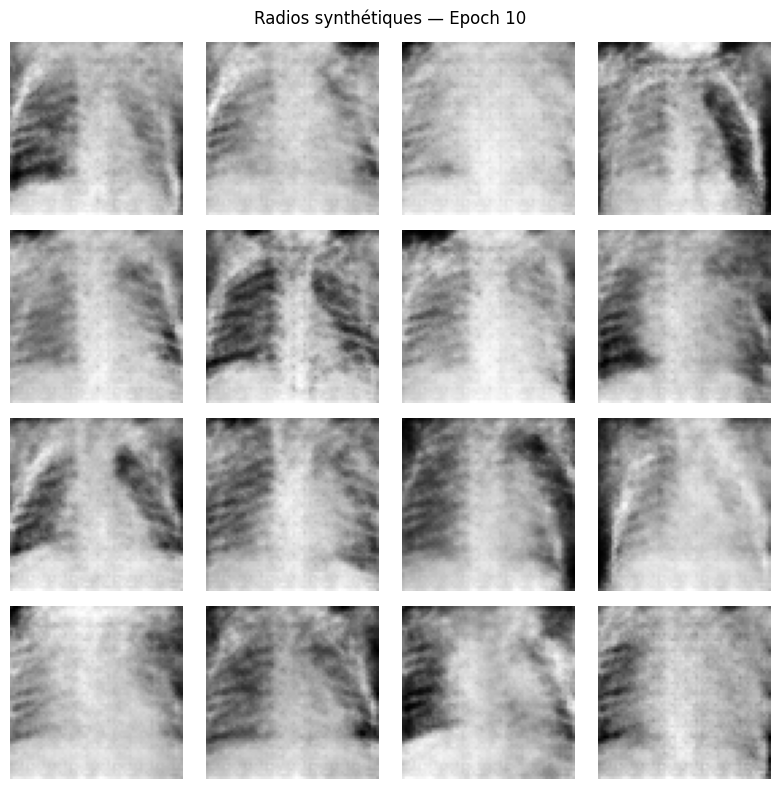

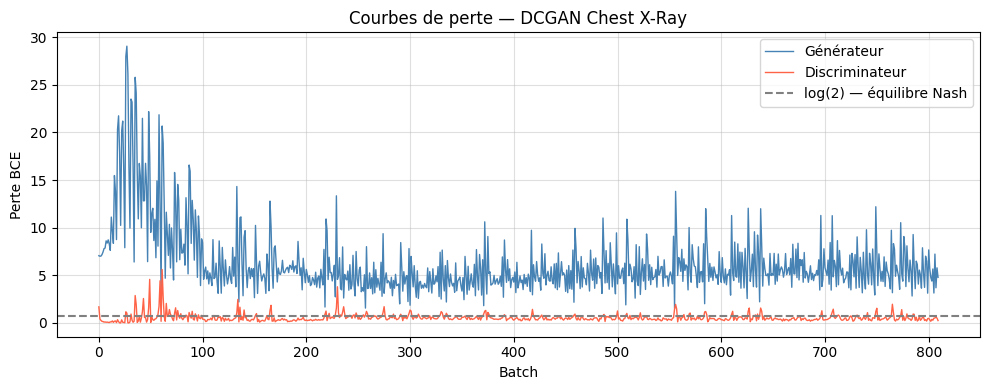


Starting epoch 10...
  Batch     0 | G_loss: 5.6005 | D_loss: 0.2270
  Batch    50 | G_loss: 4.7487 | D_loss: 0.2967

Starting epoch 11...
  Batch     0 | G_loss: 4.7617 | D_loss: 0.3324
  Batch    50 | G_loss: 6.5635 | D_loss: 0.2078

Starting epoch 12...
  Batch     0 | G_loss: 5.0693 | D_loss: 0.2138
  Batch    50 | G_loss: 4.8598 | D_loss: 0.3498

Starting epoch 13...
  Batch     0 | G_loss: 7.1011 | D_loss: 0.6011
  Batch    50 | G_loss: 4.3750 | D_loss: 0.3252

Starting epoch 14...
  Batch     0 | G_loss: 5.9003 | D_loss: 1.7622
  Batch    50 | G_loss: 4.0534 | D_loss: 0.2431

Starting epoch 15...
  Batch     0 | G_loss: 5.0660 | D_loss: 0.3776
  Batch    50 | G_loss: 4.6802 | D_loss: 0.3222

Starting epoch 16...
  Batch     0 | G_loss: 6.0539 | D_loss: 0.7410
  Batch    50 | G_loss: 5.5484 | D_loss: 0.1424

Starting epoch 17...
  Batch     0 | G_loss: 4.1279 | D_loss: 0.2813
  Batch    50 | G_loss: 5.5078 | D_loss: 0.2892

Starting epoch 18...
  Batch     0 | G_loss: 4.7726 | D

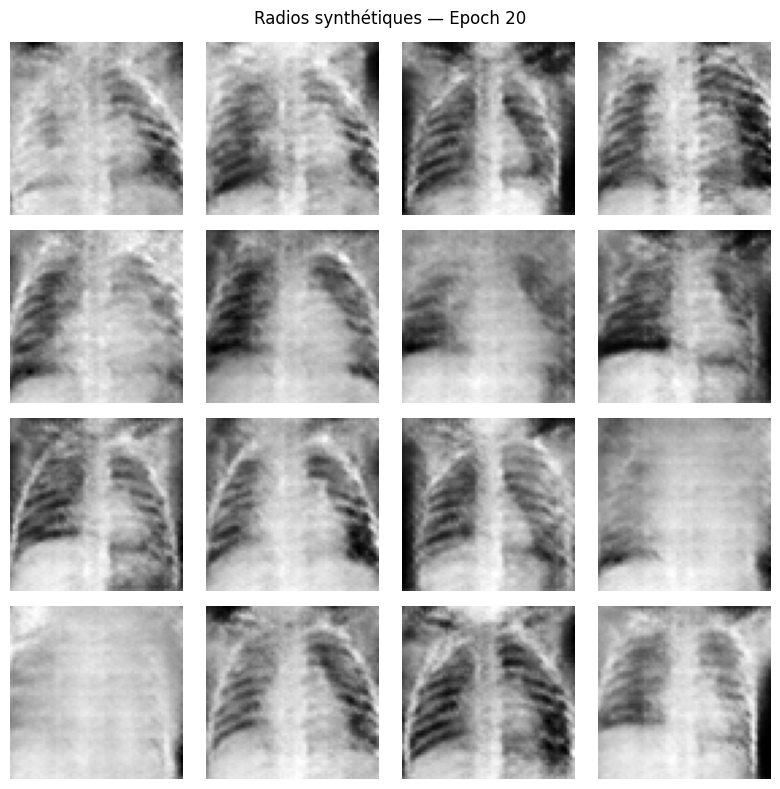

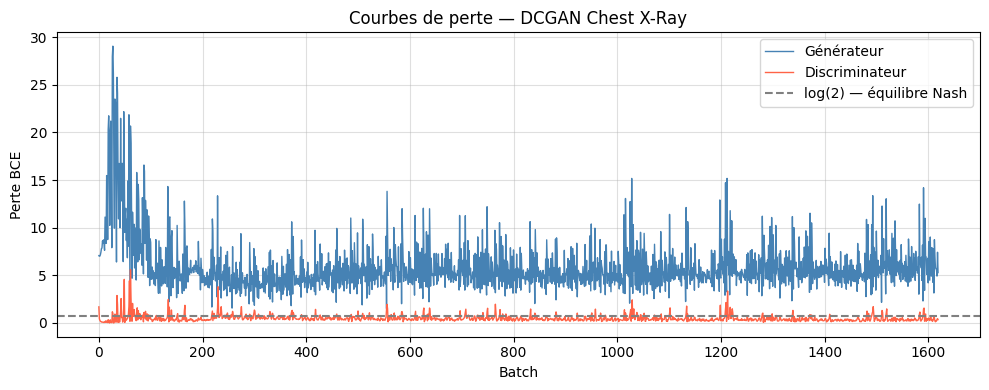


Starting epoch 20...
  Batch     0 | G_loss: 6.4704 | D_loss: 0.3904
  Batch    50 | G_loss: 3.0263 | D_loss: 0.3916

Starting epoch 21...
  Batch     0 | G_loss: 6.3922 | D_loss: 0.2226
  Batch    50 | G_loss: 5.9973 | D_loss: 1.0380

Starting epoch 22...
  Batch     0 | G_loss: 3.1141 | D_loss: 0.3392
  Batch    50 | G_loss: 5.3168 | D_loss: 1.1776

Starting epoch 23...
  Batch     0 | G_loss: 7.0442 | D_loss: 0.4884
  Batch    50 | G_loss: 4.7653 | D_loss: 0.2068

Starting epoch 24...
  Batch     0 | G_loss: 12.9734 | D_loss: 0.7248
  Batch    50 | G_loss: 5.0385 | D_loss: 0.1650

Starting epoch 25...
  Batch     0 | G_loss: 6.1799 | D_loss: 0.3471
  Batch    50 | G_loss: 6.1430 | D_loss: 0.3879

Starting epoch 26...
  Batch     0 | G_loss: 5.1964 | D_loss: 0.2067
  Batch    50 | G_loss: 3.7085 | D_loss: 0.2456

Starting epoch 27...
  Batch     0 | G_loss: 3.5029 | D_loss: 0.5942
  Batch    50 | G_loss: 5.2098 | D_loss: 0.3190

Starting epoch 28...
  Batch     0 | G_loss: 10.5909 |

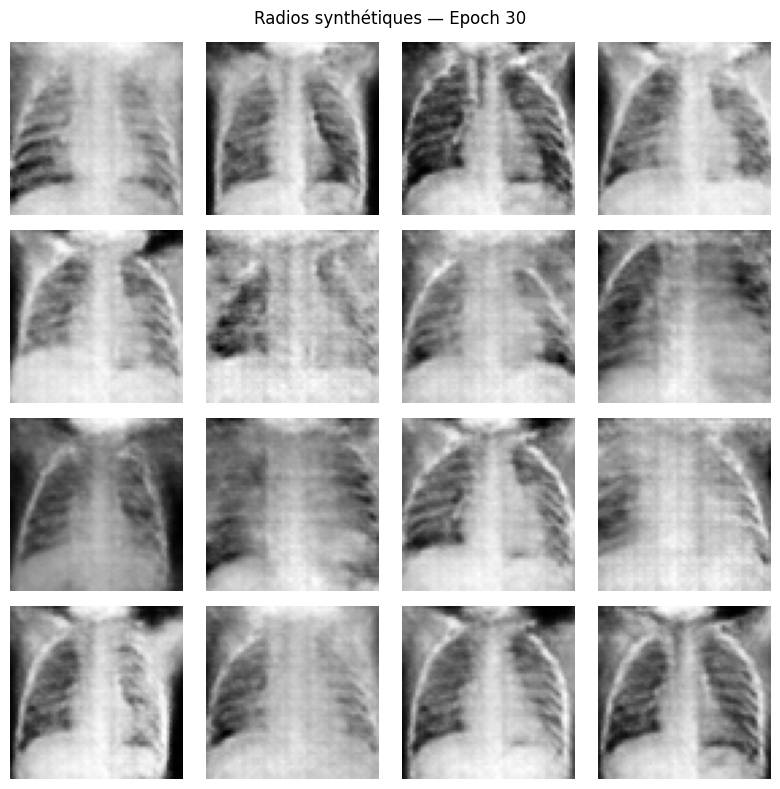

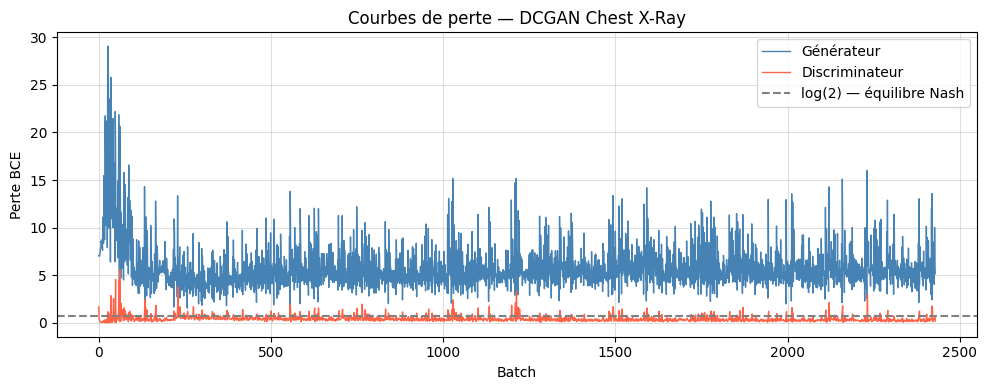


Starting epoch 30...
  Batch     0 | G_loss: 7.1633 | D_loss: 0.2278
  Batch    50 | G_loss: 4.3984 | D_loss: 0.2517

Starting epoch 31...
  Batch     0 | G_loss: 3.9417 | D_loss: 0.0751
  Batch    50 | G_loss: 6.8776 | D_loss: 0.3730

Starting epoch 32...
  Batch     0 | G_loss: 5.2021 | D_loss: 0.1275
  Batch    50 | G_loss: 5.1508 | D_loss: 0.2026

Starting epoch 33...
  Batch     0 | G_loss: 4.8863 | D_loss: 0.1899
  Batch    50 | G_loss: 5.8617 | D_loss: 0.1224

Starting epoch 34...
  Batch     0 | G_loss: 6.1769 | D_loss: 0.1364
  Batch    50 | G_loss: 4.9931 | D_loss: 0.1874

Starting epoch 35...
  Batch     0 | G_loss: 4.9989 | D_loss: 0.1827
  Batch    50 | G_loss: 7.0591 | D_loss: 0.3398

Starting epoch 36...
  Batch     0 | G_loss: 6.0488 | D_loss: 0.1878
  Batch    50 | G_loss: 5.4377 | D_loss: 0.3367

Starting epoch 37...
  Batch     0 | G_loss: 7.4976 | D_loss: 0.2417
  Batch    50 | G_loss: 4.1460 | D_loss: 0.2381

Starting epoch 38...
  Batch     0 | G_loss: 7.4587 | D

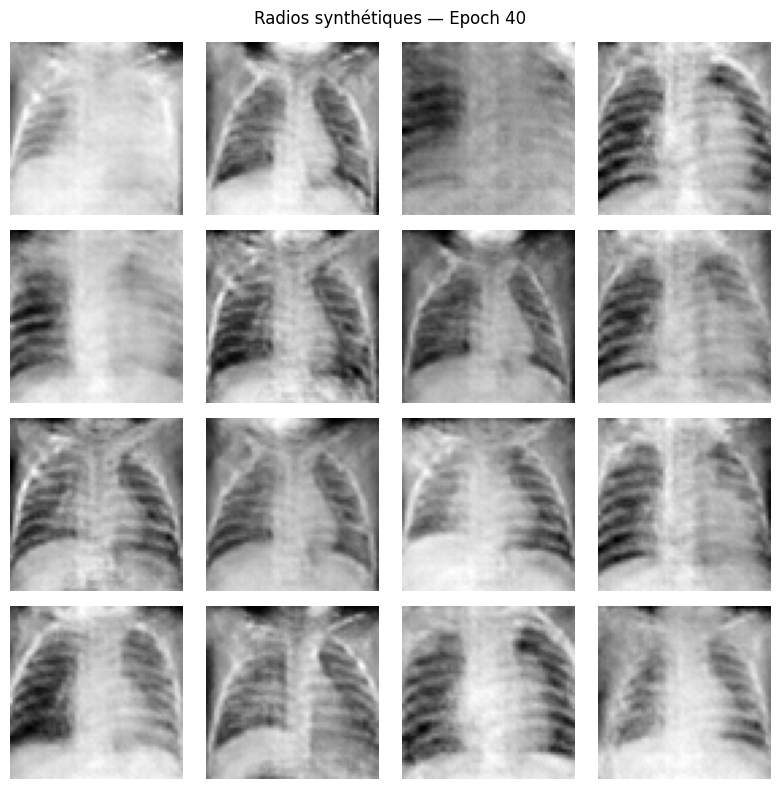

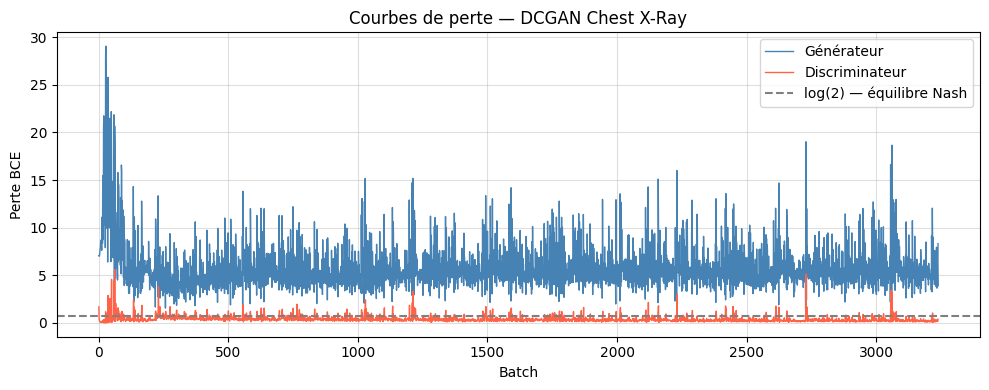


Starting epoch 40...
  Batch     0 | G_loss: 5.8441 | D_loss: 0.3872
  Batch    50 | G_loss: 5.2217 | D_loss: 0.1214

Starting epoch 41...
  Batch     0 | G_loss: 4.6407 | D_loss: 0.1991
  Batch    50 | G_loss: 5.9043 | D_loss: 0.1870

Starting epoch 42...
  Batch     0 | G_loss: 5.0950 | D_loss: 0.0979
  Batch    50 | G_loss: 4.5375 | D_loss: 0.2045

Starting epoch 43...
  Batch     0 | G_loss: 7.9712 | D_loss: 0.3528
  Batch    50 | G_loss: 4.3339 | D_loss: 0.1226

Starting epoch 44...
  Batch     0 | G_loss: 3.1076 | D_loss: 1.7834
  Batch    50 | G_loss: 6.2544 | D_loss: 0.2001

Starting epoch 45...
  Batch     0 | G_loss: 5.1909 | D_loss: 0.1398
  Batch    50 | G_loss: 3.4723 | D_loss: 0.4065

Starting epoch 46...
  Batch     0 | G_loss: 5.4744 | D_loss: 0.1155
  Batch    50 | G_loss: 5.5464 | D_loss: 0.1070

Starting epoch 47...
  Batch     0 | G_loss: 5.7959 | D_loss: 0.2293
  Batch    50 | G_loss: 3.4644 | D_loss: 0.2300

Starting epoch 48...
  Batch     0 | G_loss: 8.2569 | D

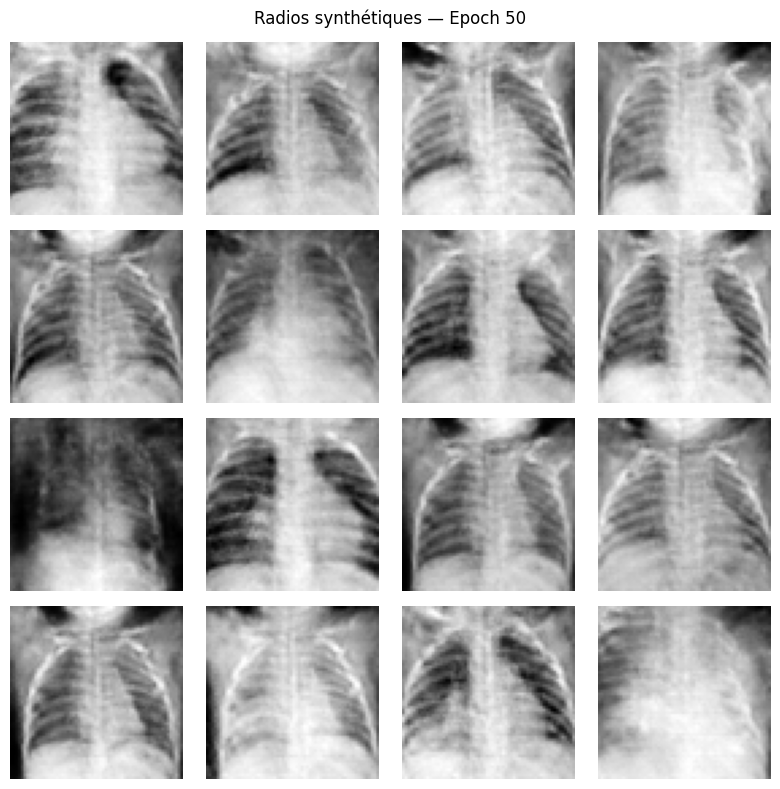

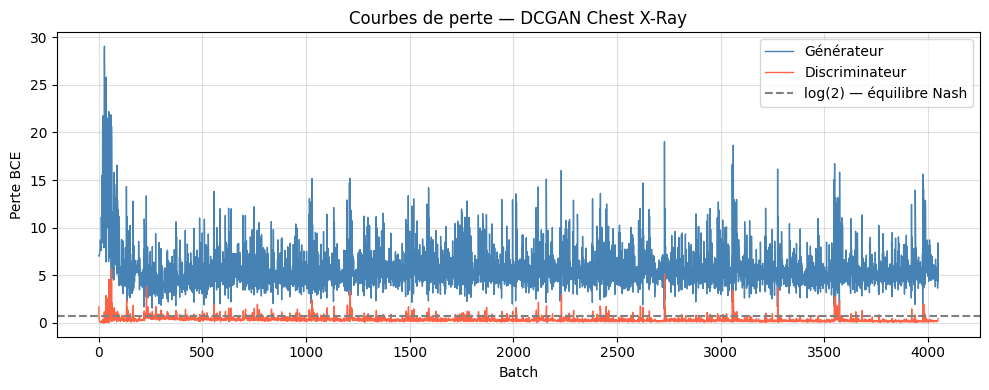


Finished unique run ce3525f9-031b-4ec7-b856-b3e650293541


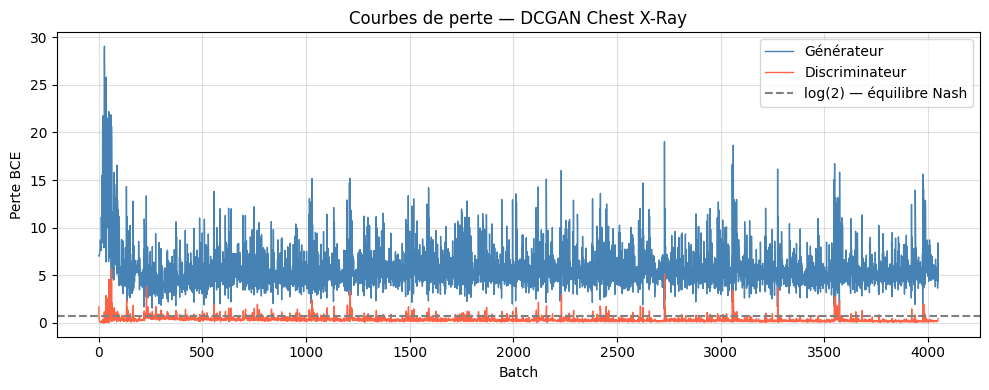

In [15]:
def train_dcgan():
    """
    Boucle principale d'entraînement du DCGAN.
    Structure identique au GAN de référence (Gan1.ipynb).
    Affichage des résultats (images générées + résumé losses) tous les 10 epochs.
    """
    make_directory_for_run()
    torch.manual_seed(42)
    device = get_device()

    # 1. Chargement des données
    dataloader = prepare_dataset()

    # 2. Initialisation des modèles (avec weights_init DCGAN)
    generator, discriminator = initialize_models(device)

    # 3. Perte et optimiseurs
    loss_function                       = initialize_loss()
    generator_optimizer, disc_optimizer = initialize_optimizers(generator, discriminator)

    print(f'DCGAN — Run {UNIQUE_RUN_ID}')
    print(f'Device : {device} | Époques : {NUM_EPOCHS} | Batch : {BATCH_SIZE}')
    print('-' * 65)

    gen_losses  = []
    disc_losses = []

    # 4. Boucle d'entraînement
    for epoch in range(NUM_EPOCHS):
        print(f'\nStarting epoch {epoch}...')
        perform_epoch(
            dataloader, generator, discriminator, loss_function,
            generator_optimizer, disc_optimizer, epoch, device,
            gen_losses, disc_losses
        )

        # ── Affichage des résultats tous les 10 epochs ──────────────────
        if (epoch + 1) % 10 == 0:
            # Nombre de batches dans cette epoch
            n_batches = len(dataloader)
            # Losses moyennes sur les n_batches de l'epoch courante
            epoch_gen_losses  = gen_losses[-n_batches:]
            epoch_disc_losses = disc_losses[-n_batches:]
            avg_g = sum(epoch_gen_losses)  / len(epoch_gen_losses)
            avg_d = sum(epoch_disc_losses) / len(epoch_disc_losses)

            print(f'\n{"="*65}')
            print(f'  Résumé Epoch {epoch + 1}/{NUM_EPOCHS}')
            print(f'  G_loss moyen : {avg_g:.4f}   |   D_loss moyen : {avg_d:.4f}')
            print(f'{"="*65}')

            # Grille 4×4 d'images générées affichée inline
            visualize_generated_grid(
                generator, device,
                title=f'Radios synthétiques — Epoch {epoch + 1}'
            )

            # Courbe de loss partielle (jusqu'à cette epoch)
            plot_loss_curves(gen_losses, disc_losses)

    print(f'\nFinished unique run {UNIQUE_RUN_ID}')

    # Courbe finale complète
    plot_loss_curves(gen_losses, disc_losses)


if __name__ == '__main__':
    train_dcgan()

**Commentaire :** La boucle principale est **volontairement quasi-identique** à `train_dcgan()` du GAN de référence (Gan1.ipynb) — seul le contenu des sous-fonctions change.

Cette cohérence structurelle est une bonne pratique en ingénierie : on peut comparer facilement les deux architectures en regardant uniquement les fonctions qui diffèrent (`Generator`, `Discriminator`, `generate_noise`, `prepare_dataset`).

**Temps d'entraînement estimé :**
- CPU : ~30-60 min/époque (pas recommandé)
- GPU (RTX 3080) : ~2-5 min/époque
- Total 50 époques : ~2-4h sur GPU

**Signe de bon fonctionnement :**
- `D_loss` converge vers ~0.69 (`log(2)`) — équilibre Nash
- `G_loss` converge vers ~0.69 aussi
- Si `D_loss → 0` → discriminateur trop fort (mode collapse risqué)
- Si `G_loss → 0` → générateur trop fort (discriminateur ne fonctionne plus)

## 12. Évaluation et visualisation des résultats

In [16]:
def visualize_generated_grid(generator, device, n_rows=4, n_cols=4, title='Radios synthétiques'):
    """
    Affiche une grille de radiographies pulmonaires générées.
    Équivalent de generate_image() mais pour l'affichage inline (sans sauvegarde).
    """
    generator.eval()
    n_images = n_rows * n_cols
    with torch.no_grad():
        noise  = generate_noise(n_images, device=device)
        images = generator(noise).cpu().numpy()   # (n, 1, 64, 64)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    for i, ax in enumerate(axes.flatten()):
        img = images[i, 0]
        img = (img + 1) / 2.0   # [-1,1] -> [0,1]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    generator.train()


def visualize_real_vs_fake(generator, dataloader, device, n=8):
    """
    Affiche côte à côte : radiographies réelles | radiographies synthétiques.
    Permet d'évaluer visuellement la qualité du générateur.
    """
    generator.eval()

    # Images réelles
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:n]

    # Images générées
    with torch.no_grad():
        noise  = generate_noise(n, device=device)
        fake_imgs = generator(noise).cpu()

    # Dénormalisation
    real_np = ((real_imgs.numpy() + 1) / 2.0).clip(0, 1)
    fake_np = ((fake_imgs.numpy() + 1) / 2.0).clip(0, 1)

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 5))
    for i in range(n):
        axes[0, i].imshow(real_np[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(fake_np[i, 0], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Réelles',     fontsize=11)
    axes[1, 0].set_ylabel('Synthétiques', fontsize=11)
    plt.suptitle('Chest X-Ray : Réelles vs Générées par DCGAN', fontsize=12)
    plt.tight_layout()
    plt.show()
    generator.train()


def plot_loss_curves(gen_losses, disc_losses):
    """
    Trace les courbes de perte du générateur et du discriminateur.
    Permet de détecter le mode collapse ou d'autres pathologies d'entraînement.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(gen_losses,  label='Générateur',     color='steelblue', linewidth=1)
    plt.plot(disc_losses, label='Discriminateur',  color='tomato',    linewidth=1)
    plt.axhline(y=0.6931, color='gray', linestyle='--', label='log(2) — équilibre Nash')
    plt.xlabel('Batch')
    plt.ylabel('Perte BCE')
    plt.title('Courbes de perte — DCGAN Chest X-Ray')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation après entraînement :
# visualize_generated_grid(generator, device)
# visualize_real_vs_fake(generator, dataloader, device)
print('Fonctions de visualisation définies.')

Fonctions de visualisation définies.


Loading models and data for visualization...
Dataset chargé : 5216 images
Classes trouvées : ['NORMAL', 'PNEUMONIA']
DataLoader : 81 batches

--- Visualisation des résultats ---


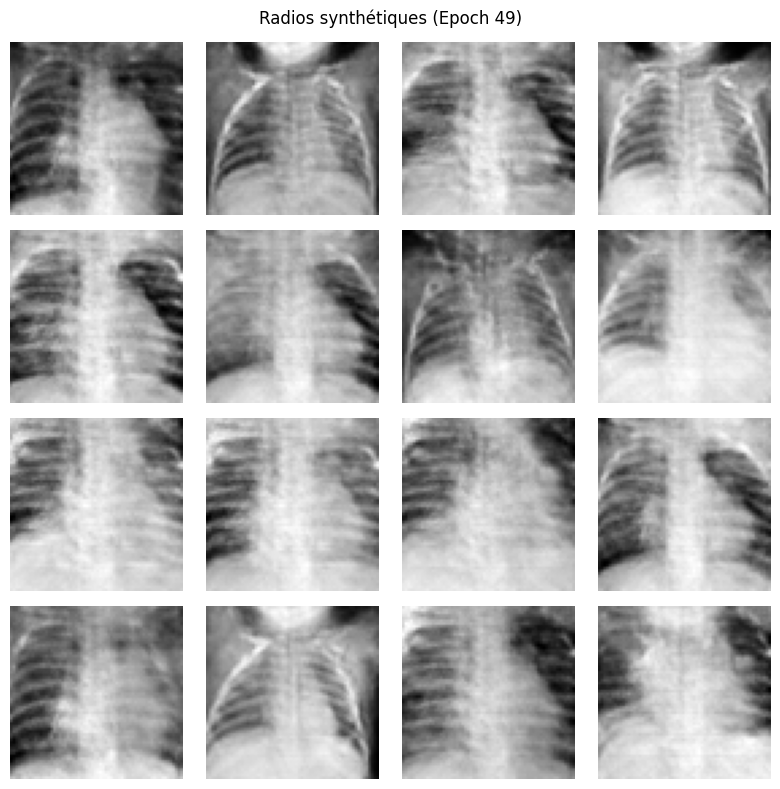

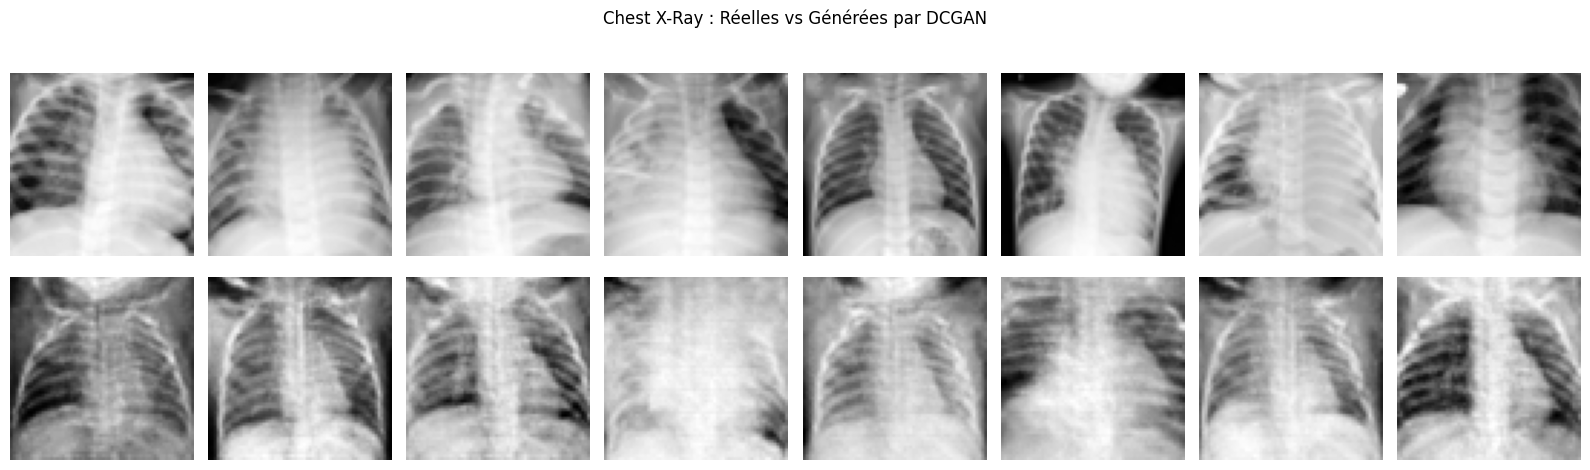

In [17]:
print('Loading models and data for visualization...')

# Re-initialize device, dataloader, and load generator for visualization
device = get_device()
dataloader = prepare_dataset() # This function is already defined and uses DATA_ROOT

# Initialize generator and load trained weights for the last epoch
generator_for_viz = Generator().to(device)
latest_epoch = NUM_EPOCHS - 1 # Assuming models are saved after each epoch, so NUM_EPOCHS-1 gives the last trained epoch index
# Check the available files from the kernel state, the latest saved generator is generator_049.pth
# So `latest_epoch` should be 49
generator_for_viz.load_state_dict(torch.load(f'./runs/{UNIQUE_RUN_ID}/generator_{latest_epoch:03d}.pth'))
generator_for_viz.eval() # Set to eval mode for visualization

print("\n--- Visualisation des résultats ---")
visualize_generated_grid(generator_for_viz, device, title=f'Radios synthétiques (Epoch {latest_epoch})')
visualize_real_vs_fake(generator_for_viz, dataloader, device, n=8)

**Commentaire :** Trois outils de visualisation pour évaluer le DCGAN :

**1. `visualize_generated_grid`** : grille de 16 images synthétiques — vision d'ensemble de la diversité du générateur. Si toutes les images se ressemblent → **mode collapse** !

**2. `visualize_real_vs_fake`** : comparaison directe réel/synthétique — outil qualitatif le plus important. En imagerie médicale, on vérifie que les structures anatomiques (bronches, côtes, diaphragme) sont présentes.

**3. `plot_loss_curves`** :
- La ligne horizontale à `log(2) ≈ 0.693` représente l'équilibre de Nash théorique — quand G et D sont parfaitement équilibrés
- D_loss stable autour de 0.69 + G_loss stable autour de 0.69 → entraînement sain
- D_loss → 0 → mode collapse imminent
- Oscillations fortes → LR trop grand ou architecture déséquilibrée

**Note médicale** : pour une utilisation clinique réelle, il faudrait compléter avec des métriques quantitatives : FID (Fréchet Inception Distance), IS (Inception Score), et idéalement une évaluation par un radiologue.